# 🐦 Listening to Extinction — Part 1
## Geographic Shift Analysis of Turkish Bird Species via Xeno-canto

> *World Biodiversity Day 2026 | Code Beyond the Earth*

This notebook analyzed habitat changes for nine different bird species using xeno-canto sound recording coordinates.

### Species — 3 categories:
| Category | Species | In Turkish|
|---|---|---|
| 🔴 Losers | Great Bustard, Red-legged Partridge, Quail | Büyük Toy, Kınalı Keklik, Bıldırcın |
| 🟢 Winners | Magpie, Swift, Red Kite | Saksağan, Ebabil, Kızıl Şahin |
| ⚪ Quiet spots | Black Vulture, Steppe Lark, Pied Flycatcher | Kara Akbaba, Bozkır Toygarı, Alaca Sinekkapan |

### Regions:
- Black Sea coast (Rize/Artvin)
- Taurus Mountains
- Central Anatolia (Konya/Tuz Gölü)
- Aegean (Izmir/Gediz Delta)
- Quiet place: Iğdır/Ağrı


---

## 0. Installation

We are installing the necessary libraries. This may take a few seconds on the first run in Colab.

In [1]:
!pip install requests pandas numpy matplotlib seaborn scikit-learn shap geopandas shapely --quiet

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import json
from collections import defaultdict

# Visual style
plt.style.use('dark_background')
COLORS = {
    'loser':   '#FF6B6B',   # red — losers
    'winner':  '#6BFF9E',   # green — winners
    'silent':  '#A8A8B3',   # grey — quite spots
    'bg':      '#0D1117',
    'accent':  '#58A6FF'
}

print('Libraries are installed.')

Libraries are installed.


## 1. Species Definitions
I define each species with its scientific name, category, and expected direction of movement. These expectations are literature-based. I will compare them with the data at the end of the analysis.

In [8]:
SPECIES = [
    # (scientific_name, turkish_name, category, expected_shift)
    # losers — habitat shrinking
    ('Otis tarda',            'Büyük Toy',          'loser',  'north/east'),
    ('Alectoris chukar',      'Kınalı Keklik',      'loser',  'high altitude'),
    ('Coturnix coturnix',     'Bıldırcın',          'loser',  'north'),

    # winners — adaptive, spreading
    ('Pica pica',             'Saksağan',         'winner', 'urban/spreading'),
    ('Apus apus',             'Ebabil',           'winner', 'stabil/increasing'),
    ('Buteo buteo',           'Kızıl Şahin',      'winner', 'stabil/spreading'),

    # Quite spots — less record, data gap
    ('Aegypius monachus',     'Kara Akbaba',      'silent', 'undetermined'),
    ('Melanocorypha calandra', 'Bozkır Toygarı',  'silent', 'narrowing'),
    ('Ficedula semitorquata', 'Alaca Sinekkapan', 'silent', 'undetermined'),
]

# color mapping
CAT_COLOR = {'loser': COLORS['loser'], 'winner': COLORS['winner'], 'silent': COLORS['silent']}
CAT_TR = {'loser': 'Losers', 'winner': 'Winners', 'silent': 'Silent Places'}

print(f'🐦 {len(SPECIES)} species defined:')
for s in SPECIES:
    print(f'  [{CAT_TR[s[2]]:15}] {s[1]:25} ({s[0]})')

🐦 9 species defined:
  [Losers         ] Büyük Toy                 (Otis tarda)
  [Losers         ] Kınalı Keklik             (Alectoris chukar)
  [Losers         ] Bıldırcın                 (Coturnix coturnix)
  [Winners        ] Saksağan                  (Pica pica)
  [Winners        ] Ebabil                    (Apus apus)
  [Winners        ] Kızıl Şahin               (Buteo buteo)
  [Silent Places  ] Kara Akbaba               (Aegypius monachus)
  [Silent Places  ] Bozkır Toygarı            (Melanocorypha calandra)
  [Silent Places  ] Alaca Sinekkapan          (Ficedula semitorquata)


## 2. Extracting Data from the Xeno-canto API

**Strategy:** Instead of extracting data species by species, we download **all bird records** in Türkiye at once.

First, we determine the total number of records, then we extract all of them in paginated form.

```
GET https://xeno-canto.org/api/3/recordings?query=cnt:turkey+grp:birds&key=KEY&page=N
```

**API v3 Notes:**
- The `key` parameter is mandatory (obtained from the account page)
- Query tags do not work: `gen:X sp:Y` format is required
- `lng` changed to `lon` (difference from v2)
- 100 records per page (default)

> ⚠️ Do not share your key or add it to git repositories.

In [6]:
XC_API_KEY = '6db1a53534edd271afdb6fb579f5718c1510089b'  #'YOUR_API_KEY_HERE'

def check_turkey_total(api_key):
    """
    Queries the total bird record in Türkiye.
    Run it to understand the size before shooting.
    """
    base_url = 'https://xeno-canto.org/api/3/recordings'
    headers  = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}
    query    = 'cnt:turkey grp:birds'
    url      = f'{base_url}?query={requests.utils.quote(query)}&key={api_key}&page=1'

    r = requests.get(url, headers=headers, timeout=15)
    r.raise_for_status()
    data = r.json()

    total_recs    = int(data.get('numRecordings', 0))
    total_pages   = int(data.get('numPages', 0))
    total_species = int(data.get('numSpecies', 0))

    print('📊 Xeno-canto Bird Data of Turkey')
    print(f' Total records: {total_recs:,}')
    print(f' Total types: {total_species:,}')
    print(f' Total pages: {total_pages}')
    print(f' Estimated time: ~{total_pages} seconds ({total_pages/60:.1f} minutes)')

    return total_pages


def fetch_all_turkey_birds(api_key, max_pages=None):
    """
    Pulls all bird records in Türkiye from Xeno-canto.

    Instead of pulling by species, we use the query cnt:turkey grp:birds. This approach:
    - Faster (single query, many pages)
    - More comprehensive (we don't miss any species)
    - More honest (we also see data gaps)

    Returns:
      list: All raw records
    """
    base_url = 'https://xeno-canto.org/api/3/recordings'
    headers  = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}
    query    = 'cnt:turkey grp:birds'
    all_recordings = []

    # Total page count
    url = f'{base_url}?query={requests.utils.quote(query)}&key={api_key}&page=1'
    r   = requests.get(url, headers=headers, timeout=15)
    r.raise_for_status()
    first_page = r.json()

    total_pages = int(first_page.get('numPages', 1))
    if max_pages:
        total_pages = min(total_pages, max_pages)

    all_recordings.extend(first_page.get('recordings', []))
    print(f'  Page  1/{total_pages} — {len(all_recordings)} records (total)')

    for page in range(2, total_pages + 1):
        time.sleep(1)
        url = f'{base_url}?query={requests.utils.quote(query)}&key={api_key}&page={page}'
        try:
            r = requests.get(url, headers=headers, timeout=15)
            r.raise_for_status()
            recs = r.json().get('recordings', [])
            all_recordings.extend(recs)
            print(f'  Page {page:2d}/{total_pages} — {len(all_recordings)} records (total)')
        except Exception as e:
            print(f'  ⚠️ Page {page} skipped: {e}')

    return all_recordings


# Check the size
print('🔍 Data size is checking...\n')
total_pages = check_turkey_total(XC_API_KEY)
print()

# Sonra tamamını çek
print('🚀 Bird data is being collected across Turkey...\n')
all_turkey_recs = fetch_all_turkey_birds(XC_API_KEY)
print(f'\n✅ Total {len(all_turkey_recs):,} records downloaded')

🔍 Data size is checking...

📊 Xeno-canto Bird Data of Turkey
 Total records: 2,303
 Total types: 256
 Total pages: 24
 Estimated time: ~24 seconds (0.4 minutes)

🚀 Bird data is being collected across Turkey...

  Page  1/24 — 100 records (total)
  Page  2/24 — 200 records (total)
  Page  3/24 — 300 records (total)
  Page  4/24 — 400 records (total)
  Page  5/24 — 500 records (total)
  Page  6/24 — 600 records (total)
  Page  7/24 — 700 records (total)
  Page  8/24 — 800 records (total)
  Page  9/24 — 900 records (total)
  Page 10/24 — 1000 records (total)
  Page 11/24 — 1100 records (total)
  Page 12/24 — 1200 records (total)
  Page 13/24 — 1300 records (total)
  Page 14/24 — 1400 records (total)
  Page 15/24 — 1500 records (total)
  Page 16/24 — 1600 records (total)
  Page 17/24 — 1700 records (total)
  Page 18/24 — 1800 records (total)
  Page 19/24 — 1900 records (total)
  Page 20/24 — 2000 records (total)
  Page 21/24 — 2100 records (total)
  Page 22/24 — 2200 records (total)
  Page

## 3. Data Cleaning

Preparing raw API data for analysis:
- Remove records without coordinates
- Extract year from date (`YYYY-MM-DD` → `int`)
- Filter Turkey borders with bbox (lat: 36–42.5, lon: 26–45)
- Discard records before 2000

**We generate two DataFrames:**
- `df_all` → All 256 types (general analysis + heat map)
- `df_focus` → Only our 9 focus types (detailed shift + MFCC analysis)

In [10]:
TR_LAT = (36.0, 42.5)
TR_LON = (26.0, 45.0)

# Focus species scientific names
FOCUS_SPECIES = {s[0] for s in SPECIES}

def clean_all_recordings(raw_list):
    """
    Clean all bird data of Turkey

    Returns:
        df_all   : All species for general analysis
        df_focus : Just 9 focus species for detailed analysis
    """
    # Metadata dictionary for focus species
    focus_meta = {s[0]: s for s in SPECIES}

    rows_all   = []
    rows_focus = []

    for rec in raw_list:
        # Scientific name
        sci_name = f"{rec.get('gen','')} {rec.get('sp','')}".strip()

        # Coordinate check
        try:
            lat = float(rec.get('lat', '') or 'nan')
            lon = float(rec.get('lon', '') or 'nan')
        except (ValueError, TypeError):
            continue

        if any(map(lambda x: x != x, [lat, lon])):  # nan check
            continue

        # Türkiye bbox filter
        if not (TR_LAT[0] <= lat <= TR_LAT[1] and TR_LON[0] <= lon <= TR_LON[1]):
            continue

        # Parse the year
        try:
            year = int(rec.get('date', '')[:4])
        except (ValueError, TypeError):
            continue
        if year < 2000:
            continue

        row = {
            'scientific_name': sci_name,
            'english_name':    rec.get('en', ''),
            'lat':             lat,
            'lon':             lon,
            'year':            year,
            'quality':         rec.get('q', ''),
            'recording_id':    rec.get('id', ''),
            'sound_type':      rec.get('type', ''),
            'file_url':        rec.get('file', ''),
        }
        rows_all.append(row)

        # Focus species check
        if sci_name in FOCUS_SPECIES:
            meta = focus_meta[sci_name]
            row_focus = {**row,
                'turkish_name': meta[1],
                'category':     meta[2],
            }
            rows_focus.append(row_focus)

    return pd.DataFrame(rows_all), pd.DataFrame(rows_focus)


df_all, df_focus = clean_all_recordings(all_turkey_recs)

print(f'📊 df_all   : {len(df_all):,} records, {df_all["scientific_name"].nunique()} species')
print(f'📊 df_focus : {len(df_focus):,} records, {df_focus["scientific_name"].nunique()} focus species')
print()
print('Record per focus species:')
if len(df_focus) > 0:
    summary = df_focus.groupby(['turkish_name','category']).size().reset_index(name='count')
    summary = summary.sort_values('count', ascending=False)
    for _, row in summary.iterrows():
        bar = '█' * min(row['count'], 40)
        print(f"  {row['turkish_name']:25} [{CAT_TR[row['category']]:12}] {row['count']:4d}  {bar}")
print()
print(f'Year range : {df_all["year"].min()} – {df_all["year"].max()}')
print(f'Coordinate center: lat={df_all["lat"].mean():.2f}, lon={df_all["lon"].mean():.2f}')

📊 df_all   : 2,273 records, 254 species
📊 df_focus : 45 records, 7 focus species

Record per focus species:
  Bozkır Toygarı            [Silent Places]   22  ██████████████████████
  Kınalı Keklik             [Losers      ]    7  ███████
  Saksağan                  [Winners     ]    5  █████
  Ebabil                    [Winners     ]    3  ███
  Alaca Sinekkapan          [Silent Places]    3  ███
  Kızıl Şahin               [Winners     ]    3  ███
  Bıldırcın                 [Losers      ]    2  ██

Year range : 2000 – 2026
Coordinate center: lat=38.13, lon=33.45


## 4. Geographic Belt Analysis

**Method: Weighted Centroid**

For each species, we calculate the average coordinate of the records for each year:

$$\\bar{lat}_{t} = \\frac{1}{N_t} \\sum_{i=1}^{N_t} lat_i \\quad \\text{(year } t \\text{ for)}$$

Then we apply **linear regression** to these annual centers:

- Positive slope → northern belt
- Negative slope → southern belt

**Two-level analysis:**

- `shift_all` → All 256 species (general pattern)

- `shift_focus` → Our 9 focal species (detailed comparison)

> We analyze species with records in at least 3 different years (for reliability).

In [11]:
from sklearn.linear_model import LinearRegression

def compute_centroid_shift(df, min_years=3, min_records_per_year=1):
    """
      Calculates the annual habitat center and belt slope for each species.

      Args:
            df: Record DataFrame (must have scientific_name, lat, lon, year columns)
            min_years: Minimum number of years for regression
            min_records_per_year: Minimum number of records per year

      Returns:
            centroid_df: Annual centers
            shift_df: Belt summary per species
    """
    centroid_rows = []
    shift_rows    = []

    for sci_name, group in df.groupby('scientific_name'):
        # Metadata — focus species check
        tr_name  = group['turkish_name'].iloc[0] if 'turkish_name' in group.columns else sci_name
        category = group['category'].iloc[0] if 'category' in group.columns else 'all'
        en_name  = group['english_name'].iloc[0] if 'english_name' in group.columns else ''

        # Yearly center
        yearly = (
            group.groupby('year')
            .agg(lat=('lat','mean'), lon=('lon','mean'), n=('lat','count'))
            .reset_index()
        )
        yearly = yearly[yearly['n'] >= min_records_per_year]

        for _, row in yearly.iterrows():
            centroid_rows.append({
                'scientific_name': sci_name,
                'turkish_name':    tr_name,
                'english_name':    en_name,
                'category':        category,
                'year':            row['year'],
                'centroid_lat':    row['lat'],
                'centroid_lon':    row['lon'],
                'n_records':       row['n'],
            })

        if len(yearly) < min_years:
            shift_rows.append({
                'scientific_name': sci_name,
                'turkish_name':    tr_name,
                'english_name':    en_name,
                'category':        category,
                'lat_slope':       float('nan'),
                'lon_slope':       float('nan'),
                'lat_r2':          float('nan'),
                'total_records':   len(group),
                'years_available': len(yearly),
                'sufficient_data': False,
            })
            continue

        X = yearly['year'].values.reshape(-1, 1)
        reg_lat = LinearRegression().fit(X, yearly['lat'].values)
        reg_lon = LinearRegression().fit(X, yearly['lon'].values)

        shift_rows.append({
            'scientific_name': sci_name,
            'turkish_name':    tr_name,
            'english_name':    en_name,
            'category':        category,
            'lat_slope':       reg_lat.coef_[0],
            'lon_slope':       reg_lon.coef_[0],
            'lat_r2':          reg_lat.score(X, yearly['lat'].values),
            'total_records':   len(group),
            'years_available': len(yearly),
            'sufficient_data': True,
        })

    return pd.DataFrame(centroid_rows), pd.DataFrame(shift_rows)


# --- Analysis for all species---
print('🔍 Belt analysis for all species...')

# df_all does not contains category and turkish_name, let's add
focus_meta = {s[0]: (s[1], s[2]) for s in SPECIES}
df_all['turkish_name'] = df_all['scientific_name'].map(
    lambda x: focus_meta[x][0] if x in focus_meta else x
)
df_all['category'] = df_all['scientific_name'].map(
    lambda x: focus_meta[x][1] if x in focus_meta else 'other'
)

centroid_all, shift_all = compute_centroid_shift(df_all, min_years=3, min_records_per_year=1)
centroid_focus, shift_focus = compute_centroid_shift(df_focus, min_years=3, min_records_per_year=1)

suf_all   = shift_all[shift_all['sufficient_data']]
suf_focus = shift_focus[shift_focus['sufficient_data']]

print(f'\n📊 All species  : {len(shift_all)} species analyzed, {len(suf_all)} have enough data')
print(f'📊 Focus species : {len(shift_focus)} species analyzed, {len(suf_focus)} have enough data')
print()
if len(suf_all) > 0:
    north = suf_all[suf_all['lat_slope'] > 0]
    south = suf_all[suf_all['lat_slope'] < 0]
    print(f'All species shifting northward: {len(north)} species ({len(north)/len(suf_all)*100:.0f}%)')
    print(f'All species shifting southward: {len(south)} species ({len(south)/len(suf_all)*100:.0f}%)')
    print(f'Average lat slope: {suf_all["lat_slope"].mean():+.5f}°/year')
    print()
    print('Top 5 species shifting northward fastest:')

    for _, r in suf_all.nlargest(5,'lat_slope').iterrows():
        print(f"  {r['english_name'] or r['scientific_name']:35} +{r['lat_slope']:.4f}°/yıl")
    print()
    print('Top 5 species shifting southward fastest:')
    for _, r in suf_all.nsmallest(5,'lat_slope').iterrows():
        print(f"  {r['english_name'] or r['scientific_name']:35} {r['lat_slope']:+.4f}°/yıl")


🔍 Belt analysis for all species...

📊 All species  : 254 species analyzed, 139 have enough data
📊 Focus species : 7 species analyzed, 4 have enough data

All species shifting northward: 56 species (40%)
All species shifting southward: 83 species (60%)
Average lat slope: -0.03708°/year

Top 5 species shifting northward fastest:
  Red-throated Pipit                  +0.8226°/yıl
  Common Cuckoo                       +0.4319°/yıl
  Meadow Pipit                        +0.3909°/yıl
  European Green Woodpecker           +0.3588°/yıl
  Long-eared Owl                      +0.3178°/yıl

Top 5 species shifting southward fastest:
  River Warbler                       -1.4800°/yıl
  Black-headed Gull                   -0.6943°/yıl
  Common Greenshank                   -0.6638°/yıl
  Northern Raven                      -0.4466°/yıl
  Common Firecrest                    -0.3987°/yıl


## 5. Visualization

### 5.1 — Map of Turkey: Habitat Centers and Strait Arrows

We calculate the first 5-year and last 5-year habitat centers for each species and draw arrows between them.

Arrow direction = stratification direction, arrow length = stratification amount.


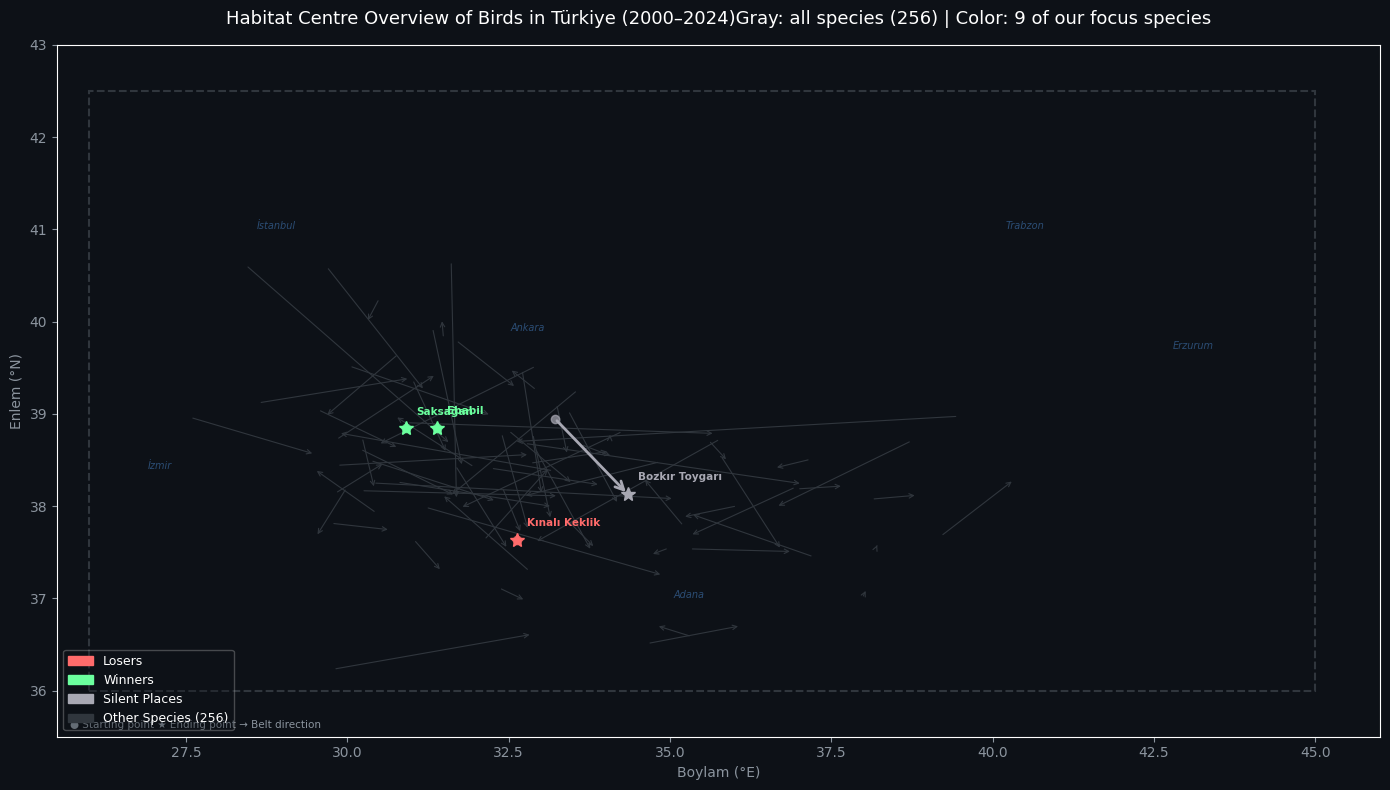

✅ turkey_bird_shift_map.png saved


In [12]:
fig, ax = plt.subplots(figsize=(14, 8), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

turkey_outline = plt.Polygon(
    [(26, 36), (45, 36), (45, 42.5), (26, 42.5)],
    fill=False, edgecolor='#30363D', linewidth=1.5, linestyle='--'
)
ax.add_patch(turkey_outline)

# City tags
cities = [
    (41.0, 28.9, 'İstanbul'), (39.9, 32.8, 'Ankara'),
    (38.4, 27.1, 'İzmir'),   (41.0, 40.5, 'Trabzon'),
    (39.7, 43.1, 'Erzurum'), (37.0, 35.3, 'Adana'),
]
for lat, lon, name in cities:
    ax.text(lon, lat, name, fontsize=7, color='#58A6FF',
            alpha=0.4, ha='center', style='italic')

import matplotlib.patches as mpatches
legend_patches = []
plotted_categories = set()

# --- All types: pale grey arrows ---
for _, shift_row in shift_all[shift_all['sufficient_data']].iterrows():
    sci_name = shift_row['scientific_name']
    category = shift_row['category']

    # I will draw the focus types separately.
    if sci_name in {s[0] for s in SPECIES}:
        continue

    sp_centroids = centroid_all[centroid_all['scientific_name'] == sci_name].sort_values('year')
    if len(sp_centroids) < 3:
        continue

    early = sp_centroids.head(5)
    late  = sp_centroids.tail(5)
    sx, sy = early['centroid_lon'].mean(), early['centroid_lat'].mean()
    ex, ey = late['centroid_lon'].mean(),  late['centroid_lat'].mean()

    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
        arrowprops=dict(arrowstyle='->', color='#30363D', lw=0.8, mutation_scale=8))

# --- Focus types: brightly colored arrows ---
for _, shift_row in shift_focus[shift_focus['sufficient_data']].iterrows():
    sci_name = shift_row['scientific_name']
    category = shift_row['category']
    tr_name  = shift_row['turkish_name']
    color    = CAT_COLOR[category]

    sp_centroids = centroid_focus[centroid_focus['scientific_name'] == sci_name].sort_values('year')
    if len(sp_centroids) < 3:
        continue

    early = sp_centroids.head(5)
    late  = sp_centroids.tail(5)
    sx, sy = early['centroid_lon'].mean(), early['centroid_lat'].mean()
    ex, ey = late['centroid_lon'].mean(),  late['centroid_lat'].mean()

    ax.plot([sx], [sy], 'o', color=color, markersize=6, alpha=0.7, zorder=5)
    ax.plot([ex], [ey], '*', color=color, markersize=10, zorder=6)
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
        arrowprops=dict(arrowstyle='->', color=color, lw=2.0, mutation_scale=15))
    ax.text(ex+0.15, ey+0.15, tr_name, fontsize=7.5,
            color=color, fontweight='bold', zorder=7)

    if category not in plotted_categories:
        legend_patches.append(mpatches.Patch(color=color, label=CAT_TR[category]))
        plotted_categories.add(category)

# legend for all species
legend_patches.append(mpatches.Patch(color='#30363D', label='Other Species (256)'))

ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          framealpha=0.3, facecolor=COLORS['bg'])
ax.set_xlim(25.5, 46)
ax.set_ylim(35.5, 43)
ax.set_xlabel('Boylam (°E)', color='#8B949E', fontsize=10)
ax.set_ylabel('Enlem (°N)', color='#8B949E', fontsize=10)
ax.tick_params(colors='#8B949E')
ax.set_title(
    'Habitat Centre Overview of Birds in Türkiye (2000–2024)'
'Gray: all species (256) | Color: 9 of our focus species',
    color='white', fontsize=13, pad=15
)
ax.text(0.01, 0.01,
    '● Starting point ★ Ending point → Belt direction',
    transform=ax.transAxes, fontsize=7.5, color='#8B949E', verticalalignment='bottom')

plt.tight_layout()
plt.savefig('turkey_bird_shift_map.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('✅ turkey_bird_shift_map.png saved')


### 5.2 — Annual Enrollment Density by Category

Are "quiet places" truly quiet, or did observers simply not visit?

This graph shows the change in the number of entries over the years, categorized by type.

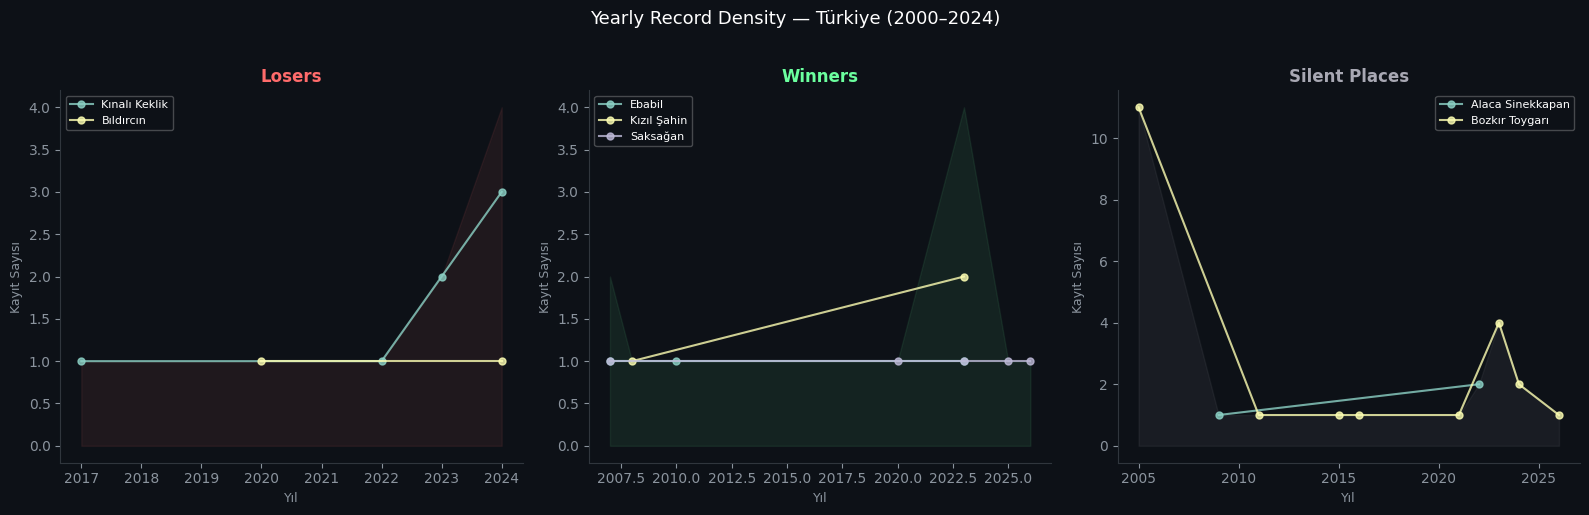

✅ Record Density Graph Saved: turkey_bird_density.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=COLORS['bg'])

for ax, (category, cat_label) in zip(axes, CAT_TR.items()):
    ax.set_facecolor(COLORS['bg'])
    color = CAT_COLOR[category]

    cat_df = df_focus[df_focus['category'] == category]

    if len(cat_df) == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', color='white')
        continue

    # Yearly record count per species
    for sci_name, species_group in cat_df.groupby('scientific_name'):
        tr_name = species_group['turkish_name'].iloc[0]
        yearly_counts = species_group.groupby('year').size().reset_index(name='count')
        ax.plot(
            yearly_counts['year'], yearly_counts['count'],
            'o-', label=tr_name, alpha=0.8, linewidth=1.5, markersize=5
        )

    # category average
    cat_yearly = cat_df.groupby('year').size().reset_index(name='count')
    ax.fill_between(cat_yearly['year'], cat_yearly['count'],
                    alpha=0.08, color=color)

    ax.set_title(cat_label, color=color, fontsize=12, fontweight='bold')
    ax.set_xlabel('Yıl', color='#8B949E', fontsize=9)
    ax.set_ylabel('Kayıt Sayısı', color='#8B949E', fontsize=9)
    ax.tick_params(colors='#8B949E')
    ax.legend(fontsize=8, framealpha=0.3, facecolor=COLORS['bg'],
              labelcolor='white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#30363D')

fig.suptitle(
    'Yearly Record Density — Türkiye (2000–2024)',
    color='white', fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig('turkey_bird_density.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Record Density Graph Saved: turkey_bird_density.png')

### 5.3 — Latitude Slope Summary Chart

We show the north-south lattice slope of each type using a bar chart.

Positive = northward lattice, negative = southward lattice.

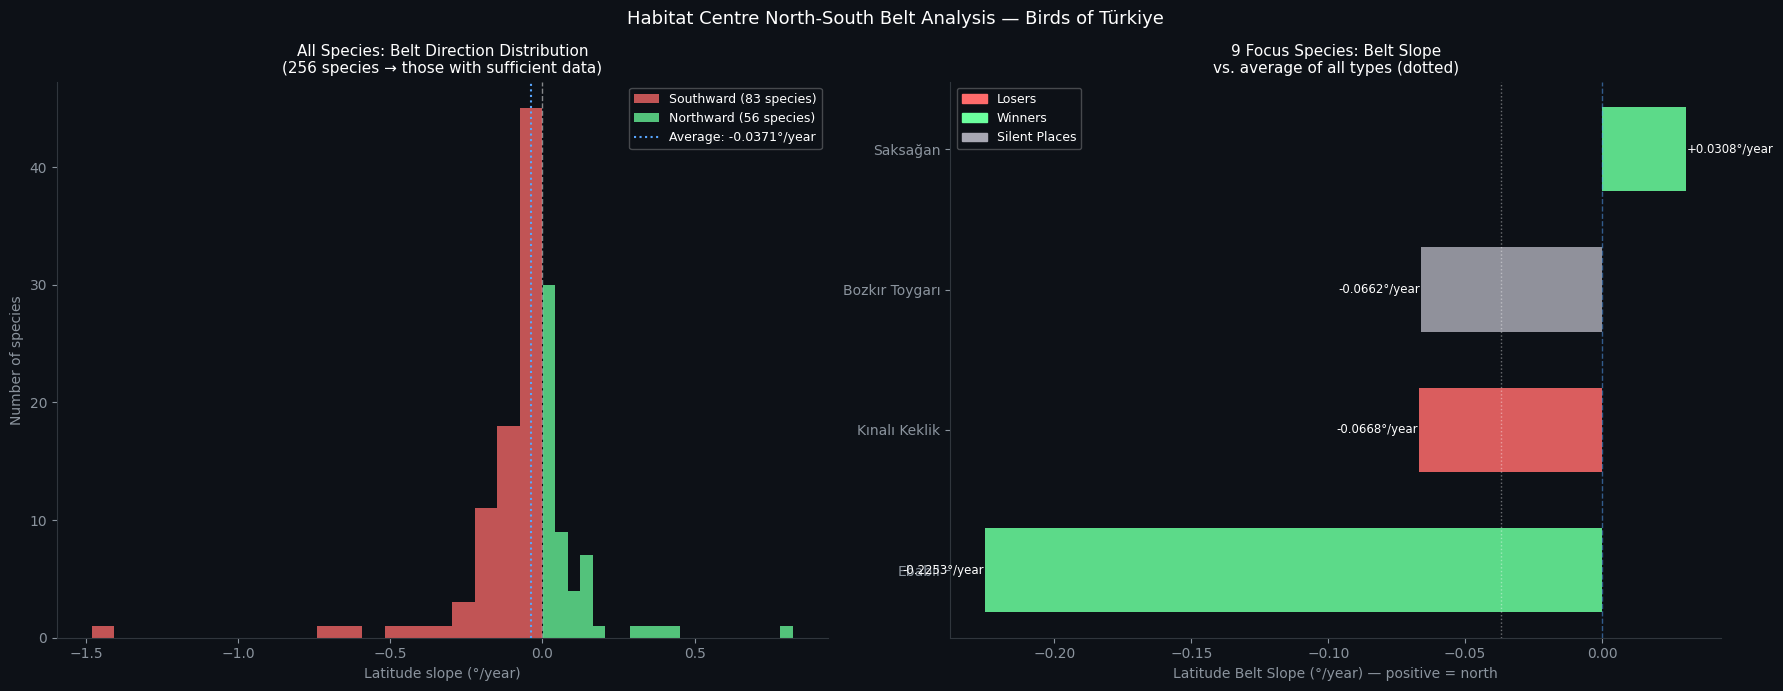

✅ turkey_bird_slope.png saved


In [16]:
# All species latitude slope summary
suf = shift_all[shift_all['sufficient_data']].copy()
suf = suf.sort_values('lat_slope')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=COLORS['bg'])

# --- Left: histogram for all species ---
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg'])

north = suf[suf['lat_slope'] > 0]['lat_slope']
south = suf[suf['lat_slope'] < 0]['lat_slope']

ax1.hist(south, bins=20, color=COLORS['loser'],  alpha=0.75, label=f'Southward ({len(south)} species)')
ax1.hist(north, bins=20, color=COLORS['winner'], alpha=0.75, label=f'Northward ({len(north)} species)')
ax1.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax1.axvline(suf['lat_slope'].mean(), color=COLORS['accent'],
            linewidth=1.5, linestyle=':', label=f'Average: {suf["lat_slope"].mean():+.4f}°/year')

ax1.set_xlabel('Latitude slope (°/year)', color='#8B949E', fontsize=10)
ax1.set_ylabel('Number of species', color='#8B949E', fontsize=10)
ax1.tick_params(colors='#8B949E')
ax1.legend(fontsize=9, framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')
ax1.set_title('All Species: Belt Direction Distribution\n(256 species → those with sufficient data)',
              color='white', fontsize=11)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#30363D')

# --- Sağ: Odak 9 tür bar chart ---
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])

plot_focus = shift_focus[shift_focus['sufficient_data']].sort_values('lat_slope')

if len(plot_focus) > 0:
    colors_focus = [CAT_COLOR[cat] for cat in plot_focus['category']]
    bars = ax2.barh(plot_focus['turkish_name'], plot_focus['lat_slope'],
                   color=colors_focus, alpha=0.85, height=0.6)
    ax2.axvline(0, color='#58A6FF', linewidth=1, linestyle='--', alpha=0.5)
    ax2.axvline(suf['lat_slope'].mean(), color='white', linewidth=1,
                linestyle=':', alpha=0.4, label='Average of all species')

    for bar, val in zip(bars, plot_focus['lat_slope']):
        x_pos = val + (0.0003 if val >= 0 else -0.0003)
        ha = 'left' if val >= 0 else 'right'
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}°/year', va='center', ha=ha,
                fontsize=8.5, color='white')

    import matplotlib.patches as mpatches
    legend_patches = [mpatches.Patch(color=CAT_COLOR[c], label=CAT_TR[c])
                      for c in ['loser','winner','silent']]
    ax2.legend(handles=legend_patches, fontsize=9,
               framealpha=0.3, facecolor=COLORS['bg'])
else:
    ax2.text(0.5, 0.5, 'Insufficient data \nfor focus species.',
             transform=ax2.transAxes, ha='center', color='white', fontsize=12)

ax2.set_xlabel('Latitude Belt Slope (°/year) — positive = north', color='#8B949E', fontsize=10)
ax2.tick_params(colors='#8B949E')
ax2.set_title('9 Focus Species: Belt Slope\nvs. average of all types (dotted)',
              color='white', fontsize=11)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#30363D')

fig.suptitle('Habitat Centre North-South Belt Analysis — Birds of Türkiye',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('turkey_bird_slope.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('✅ turkey_bird_slope.png saved')


### 5.4 — Turkey-Wide Record Heat Map

I plot the coordinates of all 256 species as a heat map across Turkey.

**Which regions are 'visible' to the observer, and which are truly silent?**

This visualization shows both citizen science bias and the actual distribution of biodiversity.


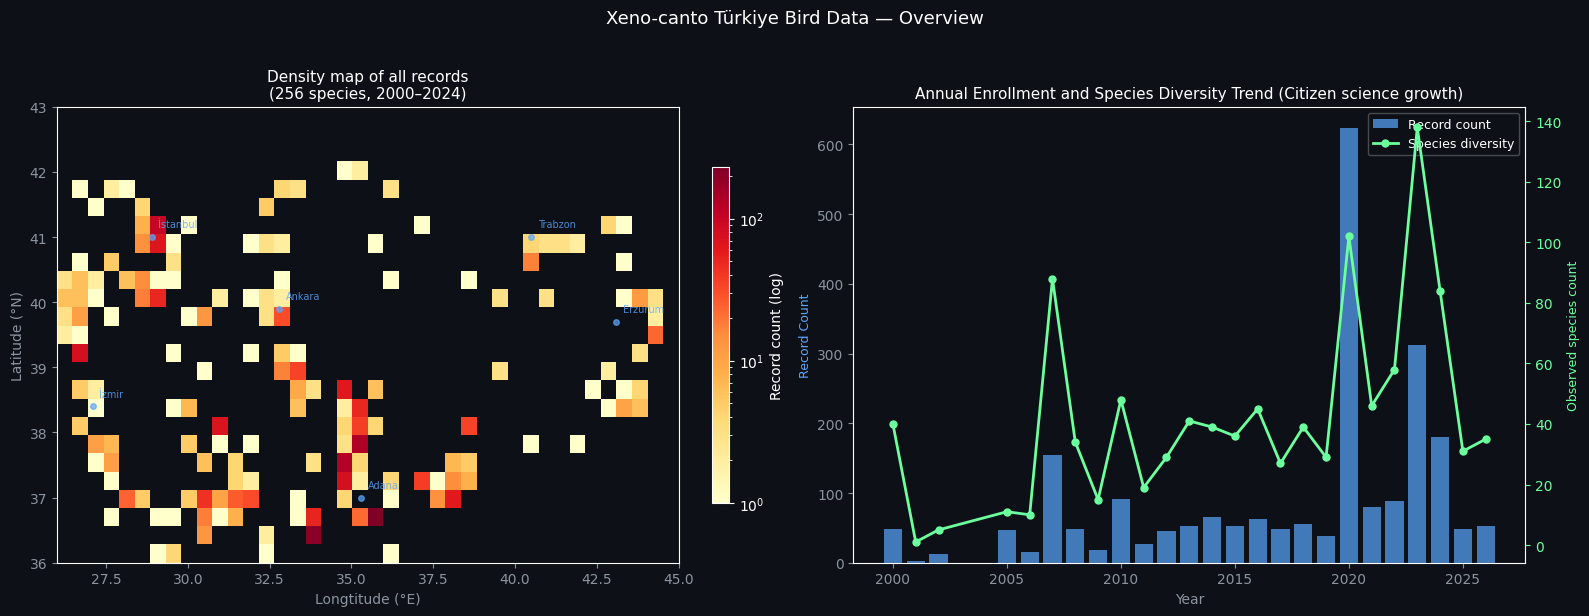

✅ turkey_birds_overview.png saved

The 10 most registered species (all of Türkiye):
  Coal Tit                         69  ██████████████████████████████████████████████████
  Identity unknown                 59  ██████████████████████████████████████████████████
  Krüper's Nuthatch                57  ██████████████████████████████████████████████████
  European Robin                   56  ██████████████████████████████████████████████████
  Great Tit                        54  ██████████████████████████████████████████████████
  Common Chiffchaff                54  ██████████████████████████████████████████████████
  Common Chaffinch                 45  █████████████████████████████████████████████
  Sardinian Warbler                41  █████████████████████████████████████████
  Western Rock Nuthatch            35  ███████████████████████████████████
  Black-headed Bunting             33  █████████████████████████████████


In [17]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=COLORS['bg'])

# --- Left: Heatmap for all species ---
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg'])

h = ax1.hist2d(
    df_all['lon'], df_all['lat'],
    bins=[40, 25],
    range=[[26, 45], [36, 43]],
    cmap='YlOrRd',
    norm=LogNorm()
)
plt.colorbar(h[3], ax=ax1, label='Record count (log)', fraction=0.025)
ax1.set_title('Density map of all records\n(256 species, 2000–2024)',
              color='white', fontsize=11)
ax1.set_xlabel('Longtitude (°E)', color='#8B949E')
ax1.set_ylabel('Latitude (°N)', color='#8B949E')
ax1.tick_params(colors='#8B949E')

# City tags
cities = [
    (41.0, 28.9, 'İstanbul'), (39.9, 32.8, 'Ankara'),
    (38.4, 27.1, 'İzmir'),   (37.0, 35.3, 'Adana'),
    (39.7, 43.1, 'Erzurum'), (41.0, 40.5, 'Trabzon'),
]
for lat, lon, name in cities:
    ax1.plot(lon, lat, 'o', color='#58A6FF', markersize=4, alpha=0.7)
    ax1.text(lon+0.2, lat+0.15, name, fontsize=7, color='#58A6FF', alpha=0.8)

# --- Right: Yearly record increase ---
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])

yearly_all = df_all.groupby('year').agg(
    n_records=('scientific_name', 'count'),
    n_species=('scientific_name', 'nunique')
).reset_index()

ax2.bar(yearly_all['year'], yearly_all['n_records'],
        color=COLORS['accent'], alpha=0.7, label='Record count')

ax2b = ax2.twinx()
ax2b.plot(yearly_all['year'], yearly_all['n_species'],
          'o-', color=COLORS['winner'], linewidth=2,
          markersize=5, label='Species diversity')
ax2b.set_ylabel('Observed species count', color=COLORS['winner'], fontsize=9)
ax2b.tick_params(colors=COLORS['winner'])
ax2b.set_facecolor(COLORS['bg'])

ax2.set_xlabel('Year', color='#8B949E')
ax2.set_ylabel('Record Count', color=COLORS['accent'], fontsize=9)
ax2.tick_params(colors='#8B949E')
ax2.set_title('Annual Enrollment and Species Diversity Trend (Citizen science growth)',
              color='white', fontsize=11)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#30363D')

# merge two legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9,
           framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')

fig.suptitle('Xeno-canto Türkiye Bird Data — Overview',
             color='white', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('turkey_birds_overview.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('✅ turkey_birds_overview.png saved')
print()
# Most registered species and areas
print('The 10 most registered species (all of Türkiye):')
top10 = df_all.groupby(['scientific_name','english_name']).size().reset_index(name='n')
top10 = top10.nlargest(10, 'n')
for _, r in top10.iterrows():
    bar = '█' * min(r['n'], 50)
    print(f"  {r['english_name']:30} {r['n']:4d}  {bar}")


## 6. Save Data

I save the cleaned data and belt summary as a CSV file.

I will use these files for Part 2 and Part 3.

In [18]:
df_all.to_csv('turkey_birds_all.csv', index=False)
df_focus.to_csv('turkey_birds_focus.csv', index=False)
shift_all.to_csv('turkey_birds_shift_all.csv', index=False)
shift_focus.to_csv('turkey_birds_shift_focus.csv', index=False)
centroid_all.to_csv('turkey_birds_centroids_all.csv', index=False)
centroid_focus.to_csv('turkey_birds_centroids_focus.csv', index=False)

print('✅ Files saved:')
print(' turkey_birds_all.csv → All bird records of Turkey (256 species)')
print(' turkey_birds_focus.csv → Records of 9 focus species')
print(' turkey_birds_shift_all.csv → Shift summary of all species')
print(' turkey_birds_shift_focus.csv → Shift summary of 9 focus species')
print(' turkey_birds_centroids_all.csv → Annual centers of all species')
print(' turkey_birds_centroids_focus.csv → Annual centers of focus species')


✅ Files saved:
 turkey_birds_all.csv → All bird records of Turkey (256 species)
 turkey_birds_focus.csv → Records of 9 focus species
 turkey_birds_shift_all.csv → Shift summary of all species
 turkey_birds_shift_focus.csv → Shift summary of 9 focus species
 turkey_birds_centroids_all.csv → Annual centers of all species
 turkey_birds_centroids_focus.csv → Annual centers of focus species


## 7. Findings and Blog Notes

In [19]:
print('=== FINDINGS SUMMARY ===')
print()

suf_all   = shift_all[shift_all['sufficient_data']]
suf_focus = shift_focus[shift_focus['sufficient_data']]

if len(suf_all) > 0:
    north = suf_all[suf_all['lat_slope'] > 0]
    south = suf_all[suf_all['lat_slope'] < 0]
    print(f'ALL SPECIES ({len(suf_all)} species — sufficient data available):')
    print(f' Northward shift: {len(north)} species ({len(north)/len(suf_all)*100:.0f}%)')
    print(f' Southward shift: {len(south)} species ({len(south)/len(suf_all)*100:.0f}%)')
    print(f' Average slope: {suf_all["lat_slope"].mean():+.5f}°/year')
    print()

if len(suf_focus) > 0:
    print('FOCUS SPECIES:')
    for _, r in suf_focus.sort_values('lat_slope', ascending=False).iterrows():
        yön = '↑ north' if r['lat_slope'] > 0 else '↓ south'
        print(f"  {r['turkish_name']:25} {r['lat_slope']:+.4f}°/year  {yön}  [{CAT_TR[r['category']]}]")
    print()

# Sessiz türler
no_data = shift_all[~shift_all['sufficient_data']]
print(f'INSUFFICIENT DATA: {len(no_data)} belt analysis could not be performed for this species.')
print(f' → There are no records of this type {no_data["total_records"].eq(0).sum()}')
print(f' → This silence is also data: observer gap or habitat loss?')


=== FINDINGS SUMMARY ===

ALL SPECIES (139 species — sufficient data available):
 Northward shift: 56 species (40%)
 Southward shift: 83 species (60%)
 Average slope: -0.03708°/year

FOCUS SPECIES:
  Saksağan                  +0.0308°/year  ↑ north  [Winners]
  Bozkır Toygarı            -0.0662°/year  ↓ south  [Silent Places]
  Kınalı Keklik             -0.0668°/year  ↓ south  [Losers]
  Ebabil                    -0.2253°/year  ↓ south  [Winners]

INSUFFICIENT DATA: 115 belt analysis could not be performed for this species.
 → There are no records of this type 0
 → This silence is also data: observer gap or habitat loss?


## 8. MFCC Feature Extraction — Basics for Part 2

**Mel-Frequency Cepstral Coefficients (MFCC)** summarizes the spectral characteristics of an audio signal.

It works similarly to how the human ear perceives frequencies — which is why it's so powerful in bird identification.

**Plan:**
1. Get audio URLs from all types of Xeno-canto (max 15 recordings/type)
2. Download each audio → upload with librosa → extract 13 MFCC coefficients
3. Save the feature matrix as a CSV (the classifier starts here in Part 2)
4. Two visuals:
    - **MFCC Heatmap:** Average audio fingerprint of each type
    - **PCA Scatter:** Do categories separate based on audio?

In [20]:
!pip install librosa soundfile --quiet
import librosa
import librosa.display
import soundfile as sf
import io, os, warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print('✅ librosa is ready')

✅ librosa is ready


In [23]:
def fetch_audio_urls(scientific_name, api_key, max_samples=15, quality_filter=['A','B']):
    """
    Xeno-canto API v3'ten ses dosyası URL'lerini çeker.
    """
    base_url = 'https://xeno-canto.org/api/3/recordings'
    headers  = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}

    gen, sp = scientific_name.split(' ', 1)
    query   = f'gen:{gen} sp:{sp} cnt:turkey'
    url     = f'{base_url}?query={requests.utils.quote(query)}&key={XC_API_KEY}&page=1'

    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f'  ❌ URL error ({scientific_name}): {e}')
        return []

    results = []
    for rec in data.get('recordings', []):
        if rec.get('q', '') not in quality_filter:
            continue
        file_url = rec.get('file', '')
        if not file_url:
            continue
        if file_url.startswith('//'):
            file_url = 'https:' + file_url
        results.append({
            'id':      rec.get('id'),
            'url':     file_url,
            'quality': rec.get('q'),
            'date':    rec.get('date'),
            'lat':     rec.get('lat'),
            'lng':     rec.get('lon'),  # v3'te 'lon'
        })
        if len(results) >= max_samples:
            break

    return results

def extract_mfcc_from_url(url, n_mfcc=13, duration=10, sr=22050):
    """
    Downloads an audio file from a URL and extracts MFCC features.

    Args:
        url: Audio file URL (mp3/wav/ogg)
        n_mfcc: Number of MFCC coefficients (standard: 13)
        duration: Duration to be analyzed (seconds) — trims long recordings
        sr: Sampling rate (Hz)

    Returns:
        np.array: shape (n_mfcc * 3,) — combination of mean, std, delta_mean

    Note: I calculate mean + std + delta_mean for each MFCC coefficient.
          This produces a 13 * 3 = 39-dimensional feature vector.
          Delta (derivative) captures temporal variation — much more informative than just mean.
    """
    try:
        headers = {'User-Agent': 'BiodiversityResearch/1.0 (educational)'}
        r = requests.get(url, headers=headers, timeout=20, stream=True)
        r.raise_for_status()

        # Belleğe yükle, diske yazma
        audio_bytes = io.BytesIO(r.content)

        # librosa ile yükle — mp3/ogg/wav otomatik tanır
        y, sr_actual = librosa.load(audio_bytes, sr=sr, duration=duration, mono=True)

        if len(y) < sr * 2:  # skip less than 2 second
            return None

        # MFCC calculate
        mfcc = librosa.feature.mfcc(y=y, sr=sr_actual, n_mfcc=n_mfcc)

        # Delta MFCC — temporal change
        mfcc_delta = librosa.feature.delta(mfcc)

        # For each coeff: mean, std, delta_mean → 13*3 = 39 özellik
        features = np.concatenate([
            np.mean(mfcc, axis=1),        # 13 özellik
            np.std(mfcc, axis=1),         # 13 özellik
            np.mean(mfcc_delta, axis=1),  # 13 özellik
        ])

        return features

    except Exception as e:
        return None


print('✅ Functions defined')
print('fetch_audio_urls() → URL list of Turkish recordings')
print('extract_mfcc_from_url() → 39-dimensional audio fingerprint')

✅ Functions defined
fetch_audio_urls() → URL list of Turkish recordings
extract_mfcc_from_url() → 39-dimensional audio fingerprint


In [28]:
# --- Tüm türler için MFCC çekimi ---
print('🎵 MFCC extraction started... (each species ~2-3 minutes)\n')

FEATURE_COLS = (
    [f'mfcc_mean_{i}'  for i in range(13)] +
    [f'mfcc_std_{i}'   for i in range(13)] +
    [f'mfcc_delta_{i}' for i in range(13)]
)  # 39 özellik

mfcc_rows = []

for sci_name, tr_name, category, _ in SPECIES:
    print(f'→ {tr_name} ({sci_name})')

    # URL'leri çek
    audio_records = fetch_audio_urls(sci_name, api_key=XC_API_KEY, max_samples=15)
    print(f'  {len(audio_records)} quality record found', end='')

    if not audio_records:
        print(' — skipped')
        continue

    success = 0
    for rec in audio_records:
        features = extract_mfcc_from_url(rec['url'])
        if features is None:
            continue

        row = {
            'scientific_name': sci_name,
            'turkish_name':    tr_name,
            'category':        category,
            'recording_id':    rec['id'],
            'date':            rec['date'],
            'lat':             rec['lat'],
            'lng':             rec['lng'],
        }
        for col, val in zip(FEATURE_COLS, features):
            row[col] = val

        mfcc_rows.append(row)
        success += 1
        time.sleep(0.5)  # rate limit

    print(f', {success} succesfull extraction')
    time.sleep(2)

mfcc_df = pd.DataFrame(mfcc_rows)
print(f'\n✅ MFCC extracted for a total of {len(mfcc_df)} records')
print(f'Feature matrix size: {mfcc_df.shape}')
mfcc_df.to_csv('turkey_birds_mfcc.csv', index=False)
print('💾 turkey_birds_mfcc.csv saved — ready for Part 2')

🎵 MFCC extraction started... (each species ~2-3 minutes)

→ Büyük Toy (Otis tarda)
  0 quality record found — skipped
→ Kınalı Keklik (Alectoris chukar)
  3 quality record found, 3 succesfull extraction
→ Bıldırcın (Coturnix coturnix)
  0 quality record found — skipped
→ Saksağan (Pica pica)
  4 quality record found, 4 succesfull extraction
→ Ebabil (Apus apus)
  2 quality record found, 2 succesfull extraction
→ Kızıl Şahin (Buteo buteo)
  0 quality record found — skipped
→ Kara Akbaba (Aegypius monachus)
  0 quality record found — skipped
→ Bozkır Toygarı (Melanocorypha calandra)
  15 quality record found, 15 succesfull extraction
→ Alaca Sinekkapan (Ficedula semitorquata)
  2 quality record found, 2 succesfull extraction

✅ MFCC extracted for a total of 26 records
Feature matrix size: (26, 46)
💾 turkey_birds_mfcc.csv saved — ready for Part 2


### 8.1 — MFCC Heatmap: Sound Fingerprint of Each Genre

I display the average MFCC values ​​of each genre as a heatmap.

**Rows** = 13 MFCC coefficients (low → high frequency summary)

**Columns** = genres (grouped by category)

Color difference = how distinctly different the sounds are from each other.

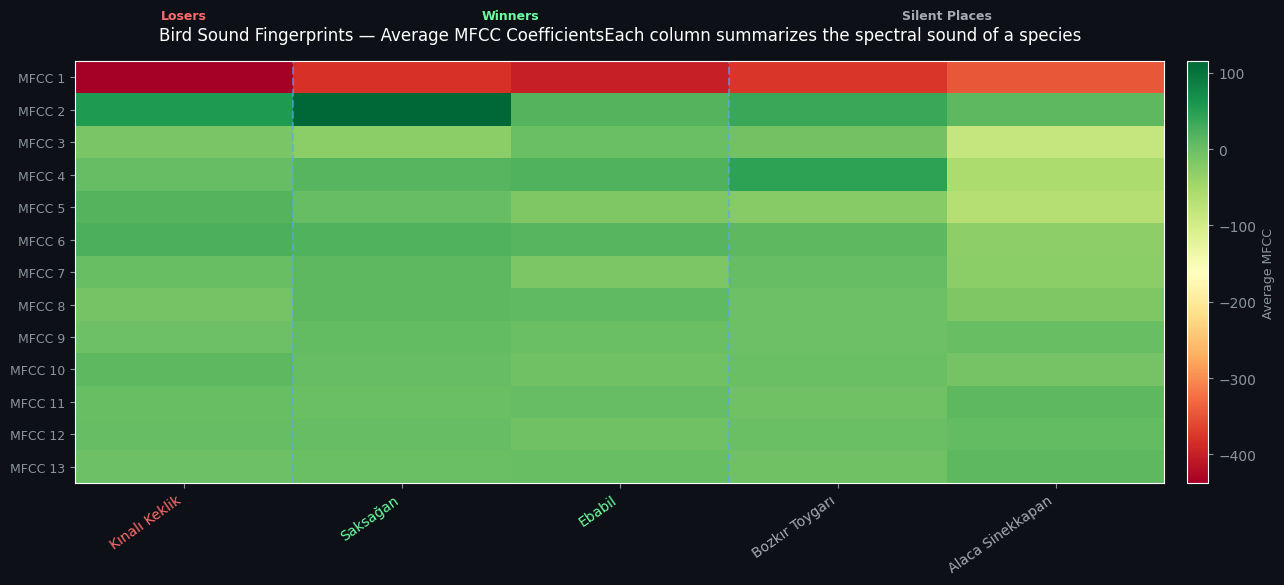

✅ turkey_birds_mfcc_heatmap.png saved


In [29]:
if len(mfcc_df) == 0:
    print('⚠️ MFCC verisi yok — veri çekimini kontrol et')
else:
    # Tür başına ortalama MFCC mean değerleri
    mean_cols = [f'mfcc_mean_{i}' for i in range(13)]

    # Kategoriye göre sırala: loser → winner → silent
    cat_order  = ['loser', 'winner', 'silent']
    species_ordered = (
        mfcc_df[['turkish_name','category']]
        .drop_duplicates()
        .sort_values('category', key=lambda x: x.map({c:i for i,c in enumerate(cat_order)}))
    )

    heatmap_data = []
    labels       = []
    cat_colors_list = []

    for _, srow in species_ordered.iterrows():
        subset = mfcc_df[mfcc_df['turkish_name'] == srow['turkish_name']]
        if len(subset) == 0:
            continue
        avg = subset[mean_cols].mean().values
        heatmap_data.append(avg)
        labels.append(srow['turkish_name'])
        cat_colors_list.append(CAT_COLOR[srow['category']])

    heatmap_matrix = np.array(heatmap_data)  # shape: (n_species, 13)

    fig, ax = plt.subplots(figsize=(13, 6), facecolor=COLORS['bg'])
    ax.set_facecolor(COLORS['bg'])

    im = ax.imshow(
        heatmap_matrix.T,   # 13 × n_species
        aspect='auto',
        cmap='RdYlGn',
        interpolation='nearest'
    )

    # axis
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    ax.set_yticks(range(13))
    ax.set_yticklabels([f'MFCC {i+1}' for i in range(13)], fontsize=9)
    ax.tick_params(colors='#8B949E')

    # species names are colored
    for tick_label, color in zip(ax.get_xticklabels(), cat_colors_list):
        tick_label.set_color(color)

    # category divider
    cat_list = [mfcc_df[mfcc_df['turkish_name']==l]['category'].iloc[0] for l in labels]
    for i in range(1, len(cat_list)):
        if cat_list[i] != cat_list[i-1]:
            ax.axvline(i - 0.5, color='#58A6FF', linewidth=1.5, alpha=0.6, linestyle='--')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Average MFCC', color='#8B949E', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#8B949E')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8B949E')

    # Category tags
    cat_positions = {}
    for i, (label, cat) in enumerate(zip(labels, cat_list)):
        cat_positions.setdefault(cat, []).append(i)
    for cat, positions in cat_positions.items():
        mid = np.mean(positions)
        ax.text(mid, -1.8, CAT_TR[cat], ha='center', fontsize=9,
                color=CAT_COLOR[cat], fontweight='bold', transform=ax.transData)

    ax.set_title(
        'Bird Sound Fingerprints — Average MFCC Coefficients'
        'Each column summarizes the spectral sound of a species',
        color='white', fontsize=12, pad=15
    )

    plt.tight_layout()
    plt.savefig('turkey_birds_mfcc_heatmap.png', dpi=150,
                bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    print('✅ turkey_birds_mfcc_heatmap.png saved')

### 8.2 — PCA Scatter: Are Categories Separated Based on Sound?

I reduce 39-dimensional MFCC feature vectors to 2 dimensions using PCA.

Each point = a sound recording. Color = category.

If the clusters are clearly separated from each other → the AI ​​can recognize birds by their sounds.

If they overlap → this is also a finding: some sounds are similar across categories.

> This graph poses the question of Part 2: *"How successful can the Classifier be?"*

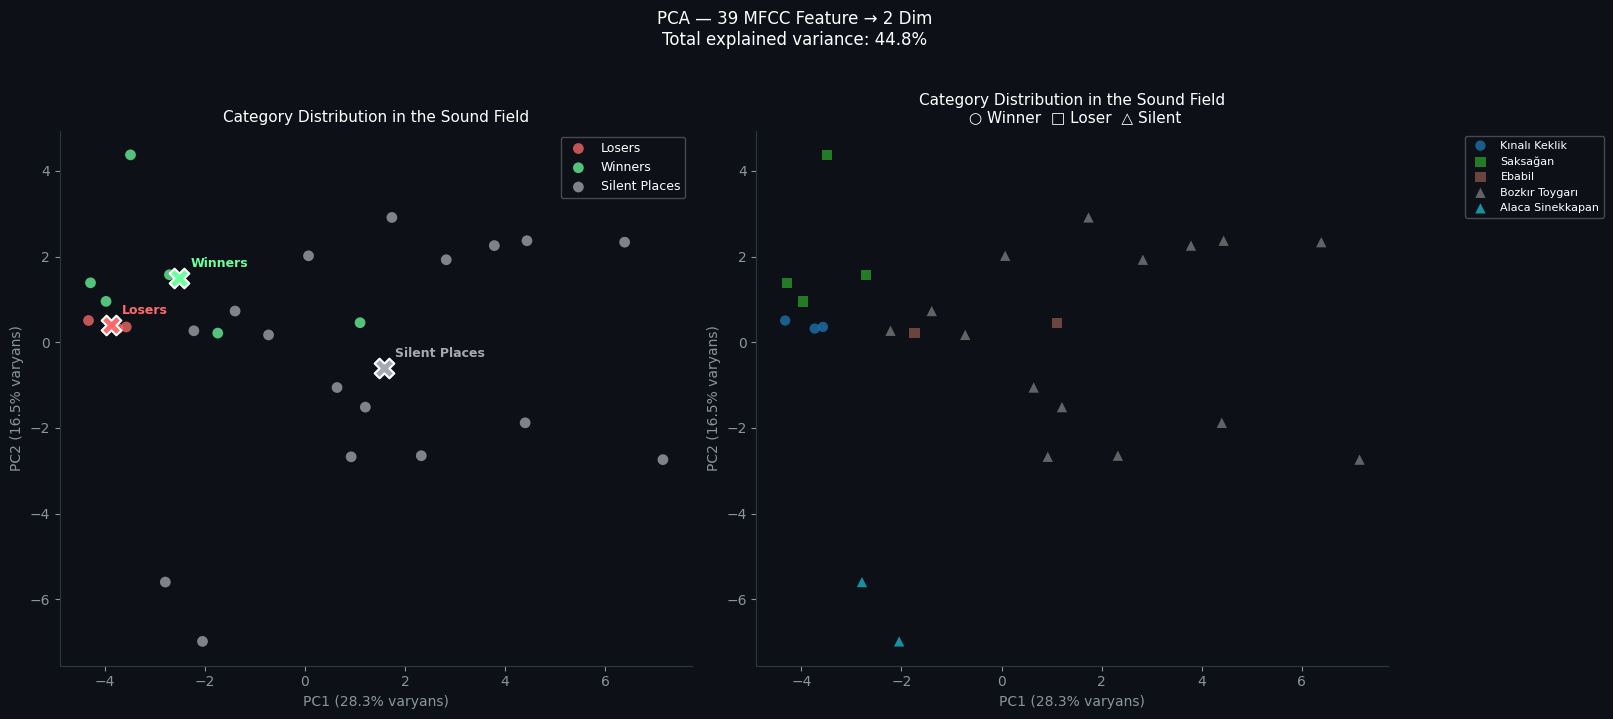

✅ turkey_birds_pca.png saved

📊 PCA Özeti:
  PC1: 28.3% varyans explained
  PC2: 16.5% varyans explained
 Total: 44.8%

 → If the sets are clearly separated: Part 2 classifier high accuracy can be expected
 → If they are nested: Which types sound similar? Why? → blog question!


In [30]:
if len(mfcc_df) < 10:
    print('⚠️ Not enough data for PCA (min 10 record needed)')
else:
    feature_cols = FEATURE_COLS
    X = mfcc_df[feature_cols].dropna().values
    valid_idx = mfcc_df[feature_cols].dropna().index
    meta = mfcc_df.loc[valid_idx]

    # Standardize — a requirement before PCA
    # Each feature has a different scale, StandardScaler equalizes them
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA — 2 feature (for visualization)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=COLORS['bg'])

    # --- Left: Category based ---
    ax1 = axes[0]
    ax1.set_facecolor(COLORS['bg'])

    for category in ['loser', 'winner', 'silent']:
        mask = meta['category'].values == category
        ax1.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=CAT_COLOR[category],
            label=CAT_TR[category],
            alpha=0.75, s=60, edgecolors='none'
        )

    # Category centers
    for category in ['loser', 'winner', 'silent']:
        mask = meta['category'].values == category
        if mask.sum() > 0:
            cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
            ax1.scatter(cx, cy, c=CAT_COLOR[category], s=200,
                        marker='X', edgecolors='white', linewidths=1.5, zorder=10)
            ax1.annotate(CAT_TR[category], (cx, cy),
                         textcoords='offset points', xytext=(8, 8),
                         fontsize=9, color=CAT_COLOR[category], fontweight='bold')

    ax1.set_xlabel(f'PC1 ({var1:.1f}% varyans)', color='#8B949E', fontsize=10)
    ax1.set_ylabel(f'PC2 ({var2:.1f}% varyans)', color='#8B949E', fontsize=10)
    ax1.tick_params(colors='#8B949E')
    ax1.legend(fontsize=9, framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')
    ax1.set_title('Category Distribution in the Sound Field', color='white', fontsize=11)
    ax1.spines[['top','right']].set_visible(False)
    ax1.spines[['left','bottom']].set_color('#30363D')

    # --- Sağ: Tür bazında ---
    ax2 = axes[1]
    ax2.set_facecolor(COLORS['bg'])

    species_list = meta['turkish_name'].unique()
    cmap = plt.cm.get_cmap('tab10', len(species_list))

    for i, sp in enumerate(species_list):
        mask = meta['turkish_name'].values == sp
        cat  = meta[meta['turkish_name']==sp]['category'].iloc[0]
        ax2.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            color=cmap(i), label=sp,
            alpha=0.75, s=55,
            marker={'loser':'o','winner':'s','silent':'^'}[cat],
            edgecolors='none'
        )

    ax2.set_xlabel(f'PC1 ({var1:.1f}% varyans)', color='#8B949E', fontsize=10)
    ax2.set_ylabel(f'PC2 ({var2:.1f}% varyans)', color='#8B949E', fontsize=10)
    ax2.tick_params(colors='#8B949E')
    ax2.legend(fontsize=8, framealpha=0.3, facecolor=COLORS['bg'],
               labelcolor='white', loc='upper right',
               bbox_to_anchor=(1.35, 1))
    ax2.set_title('Category Distribution in the Sound Field\n ○ Winner  □ Loser  △ Silent',
                  color='white', fontsize=11)
    ax2.spines[['top','right']].set_visible(False)
    ax2.spines[['left','bottom']].set_color('#30363D')

    fig.suptitle(
        f'PCA — 39 MFCC Feature → 2 Dim\n'
        f'Total explained variance: {var1+var2:.1f}%',
        color='white', fontsize=12, y=1.02
    )

    plt.tight_layout()
    plt.savefig('turkey_birds_pca.png', dpi=150,
                bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    print(f'✅ turkey_birds_pca.png saved')
    print(f'\n📊 PCA Özeti:')
    print(f'  PC1: {var1:.1f}% varyans explained')
    print(f'  PC2: {var2:.1f}% varyans explained')
    print(f' Total: {var1+var2:.1f}%')
    print(f'\n → If the sets are clearly separated: Part 2 classifier high accuracy can be expected')
    print(f' → If they are nested: Which types sound similar? Why? → blog question!')

### 8.3 — Part 2 için Export Özeti

`turkey_birds_mfcc.csv` dosyası Part 2'de doğrudan kullanılacak.
Burada ne içerdiğini özetliyoruz.

In [27]:
if len(mfcc_df) > 0:
  print('=== MFCC Dataset Summary ===')
  print(f'Total records: {len(mfcc_df)}')
  print(f'Number of features: 39 (13 MFCC mean + 13 std + 13 delta mean)')
  print()
  print('Records per type:')
  for _, row in mfcc_df.groupby(['turkish_name','category']).size().reset_index(name='n').iterrows():
    bar = '█' * row['n']
    print(f" {row['turkish_name']:25} [{CAT_TR[row['category']]:12}] {row['n']:3d} {bar}")
    print()
  print('📌 Ready files for Part 2:')
  print(' turkey_birds_mfcc.csv → MFCC feature matrix (X)')
  print(' turkey_birds_clean.csv → Coordinate + metadata')
  print()
  print('📌 Part 2 plan:')
  print(' 1. Random Forest / SVM classifier (species recognition)')
  print(' 2. SHAP values ​​→ which MFCC coefficient is the most distinctive?')
  print(' 3. Confusion matrix → which species are being confused?')
  print(' 4. Blog question: If AI can identify a bird by its sound,')
  print(' what does it mean if that sound disappears?')

=== MFCC Dataset Özeti ===
Toplam kayıt: 26
Feature sayısı: 39 (13 MFCC mean + 13 std + 13 delta mean)

Tür başına kayıt:
  Alaca Sinekkapan          [Silent Places]   2  ██
  Bozkır Toygarı            [Silent Places]  15  ███████████████
  Ebabil                    [Winners     ]   2  ██
  Kınalı Keklik             [Losers      ]   3  ███
  Saksağan                  [Winners     ]   4  ████

📌 Part 2 için hazır dosyalar:
  turkey_birds_mfcc.csv          → MFCC feature matrix (X)
  turkey_birds_clean.csv         → Koordinat + metadata

📌 Part 2 planı:
  1. Random Forest / SVM classifier (tür tanıma)
  2. SHAP değerleri → hangi MFCC katsayısı en ayırt edici?
  3. Confusion matrix → hangi türler karıştırılıyor?
  4. Blog sorusu: AI bir kuşu sesinden tanıyabiliyorsa,
     o sesin kaybolması ne anlama gelir?


---

## Methodology Note

This analysis uses the **Xeno-canto** sound recording database. Xeno-canto recordings

are not a systematic biodiversity survey, but rather voluntary observer contributions.

Therefore:
- A low number of recordings does not necessarily mean a low population
- Observer density (especially in urban areas) can affect the results
- Findings should be interpreted as **trend indicators**, not as definitive population data

**Data source:** Xeno-canto Foundation (xeno-canto.org), CC BY-NC-SA 4.0

**Analysis:** Code Beyond the Earth — Ece Özen, World Biodiversity Day 2026

---
*Continuation of the series:*

*Part 2 → How AI Listens to Birds? MFCC + Classifier + SHAP*

*Part 3 → Traces of a Sound: Embedding Similarity and Acoustic Anomaly*